In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df=pd.read_csv("final_crypto.csv")

In [3]:
df=df[df["type"]!="XRP"]
df=df[df["type"]!="BTC"]

In [4]:
train_coins = ['ETH', 'BNB', 'SOL', 'ADA']
test_coins = ['DOGE', 'AVAX']

train_df = df[df['type'].isin(train_coins)].copy()
test_df  = df[df['type'].isin(test_coins)].copy()

print("Coins in train:", train_df['type'].unique())
print("Coins in test:", test_df['type'].unique())

Coins in train: ['ETH' 'BNB' 'SOL' 'ADA']
Coins in test: ['DOGE' 'AVAX']


In [5]:
df.columns.tolist()

['date',
 'num_trades',
 'taker_buy_volume',
 'type',
 'candle_body',
 'high_low_range',
 'ma7_ratio',
 'ma30_ratio',
 'moving_1d',
 'volatility_7',
 'volumespike',
 'z_score',
 'taker_buy_ratio',
 'price_position',
 'momentum_7',
 'taker_sell_ratio',
 'negative_momentum',
 'down_days_7',
 'volatility_14',
 'volatility_3',
 'label']

Train: 52580 | Test: 26164

--- Test Results ---
              precision    recall  f1-score   support

     Bigdown       0.54      0.51      0.53      7849
       Bigup       0.58      0.54      0.56      7848
      Stable       0.59      0.65      0.62     10467

    accuracy                           0.58     26164
   macro avg       0.57      0.57      0.57     26164
weighted avg       0.57      0.58      0.57     26164



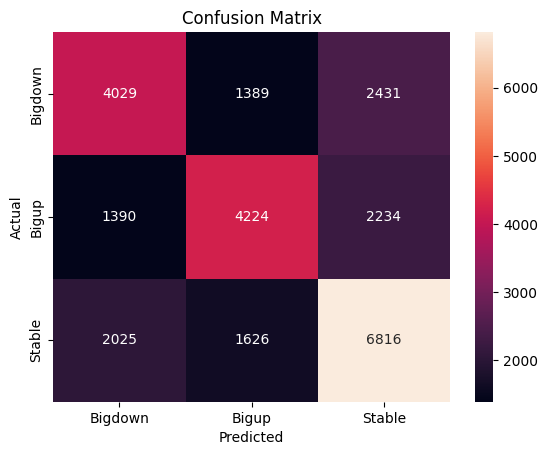

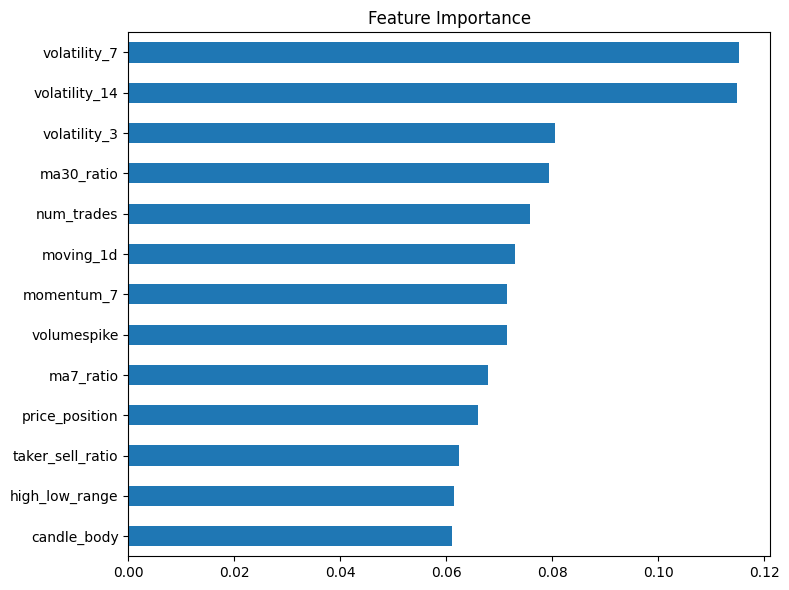

In [6]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder





drop_cols = [
    'label', 'date', 'type',
    'down_days_7',
    'taker_buy_volume',
    'z_score','taker_buy_ratio','taker_buy_ratio', 'negative_momentum',
]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df['label']

X_test = test_df.drop(columns=drop_cols)
y_test = test_df['label']


model = RandomForestClassifier(
    n_estimators=700,
    max_depth=13,
    min_samples_split=5,
    min_samples_leaf=3,
    max_features='sqrt',
    criterion='entropy',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

model.fit(X_train, y_train)






test_preds = model.predict(X_test)
print("\n--- Test Results ---")
print(classification_report(y_test, test_preds, target_names=['Bigdown', 'Bigup','Stable']))


cm = confusion_matrix(y_test, test_preds)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Bigdown', 'Bigup','Stable'],
                                     yticklabels=['Bigdown', 'Bigup','Stable'])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()


feat_imp = pd.Series(model.feature_importances_, index=X_train.columns)
feat_imp.sort_values().plot(kind='barh', figsize=(8, 6))
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

In [7]:

# Check train performance too
train_preds = model.predict(X_train)
print("--- Train Results ---")
print(classification_report(y_train, train_preds, target_names=['Bigdown', 'Bigup','Stable']))

print("--- Test Results ---")
print(classification_report(y_test, test_preds, target_names=['Bigdown', 'Bigup','Stable']))

--- Train Results ---
              precision    recall  f1-score   support

     Bigdown       0.76      0.70      0.73     15770
       Bigup       0.74      0.71      0.72     15771
      Stable       0.67      0.73      0.70     21039

    accuracy                           0.71     52580
   macro avg       0.72      0.71      0.72     52580
weighted avg       0.72      0.71      0.71     52580

--- Test Results ---
              precision    recall  f1-score   support

     Bigdown       0.54      0.51      0.53      7849
       Bigup       0.58      0.54      0.56      7848
      Stable       0.59      0.65      0.62     10467

    accuracy                           0.58     26164
   macro avg       0.57      0.57      0.57     26164
weighted avg       0.57      0.58      0.57     26164



In [8]:
print(y_train.unique())
print(sorted(y_train.unique()))

['Bigup' 'Stable' 'Bigdown']
['Bigdown', 'Bigup', 'Stable']


In [ ]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
import pandas as pd
import numpy as np

drop_cols = [
    'label', 'date', 'type',
    'down_days_7',
    'taker_buy_volume',
    'z_score','taker_buy_ratio','taker_sell_ratio', 'negative_momentum',
]

X = df.drop(columns=drop_cols)
y = df['label']

groups = df['type']

logo = LeaveOneGroupOut()

results = []

for fold, (train_idx, test_idx) in enumerate(logo.split(X, y, groups), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    test_coin = groups.iloc[test_idx].unique()[0]

    model = RandomForestClassifier(
        n_estimators=700,
        max_depth=13,
        min_samples_split=5,
        min_samples_leaf=3,
        criterion='entropy',
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    macro_f1 = f1_score(y_test, preds, average='macro')
    weighted_f1 = f1_score(y_test, preds, average='weighted')

    results.append({
        'test_coin': test_coin,
        'accuracy': acc,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1
    })

    print(f"\n===== Fold {fold} | Test coin: {test_coin} =====")
    print(classification_report(y_test, preds))

In [ ]:
results_df = pd.DataFrame(results)

print(results_df)

print("\nAverage Results:")
print(results_df[['accuracy', 'macro_f1', 'weighted_f1']].mean())

  test_coin  accuracy  macro_f1  weighted_f1
0       ADA  0.702613  0.704574     0.702574
1      AVAX  0.701473  0.703534     0.701467
2       BNB  0.467897  0.409065     0.428582
3      DOGE  0.413922  0.399840     0.411243
4       ETH  0.427398  0.416554     0.425421
5       SOL  0.395327  0.395001     0.395298

Average Results:
accuracy       0.518105
macro_f1       0.504761
weighted_f1    0.510764
dtype: float64


# SVM


In [ ]:

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

scaler = StandardScaler()

drop_cols = [
    'label', 'date', 'type',
    'down_days_7',
    'taker_buy_volume',
    'z_score',
    'taker_buy_ratio',
    'taker_sell_ratio',
    'negative_momentum',
]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df['label']

X_test = test_df.drop(columns=drop_cols)
y_test = test_df['label']

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = SVC(
    kernel='rbf',
    C=50,
    gamma='scale',
    class_weight='balanced',
    random_state=42
)

clf.fit(X_train_scaled, y_train)

predictions = clf.predict(X_test_scaled)

Accuracy: 0.4919

--- SVM Test Results ---
              precision    recall  f1-score   support

     Bigdown       0.46      0.31      0.37      7849
       Bigup       0.47      0.36      0.41      7848
      Stable       0.51      0.72      0.60     10467

    accuracy                           0.49     26164
   macro avg       0.48      0.47      0.46     26164
weighted avg       0.48      0.49      0.47     26164



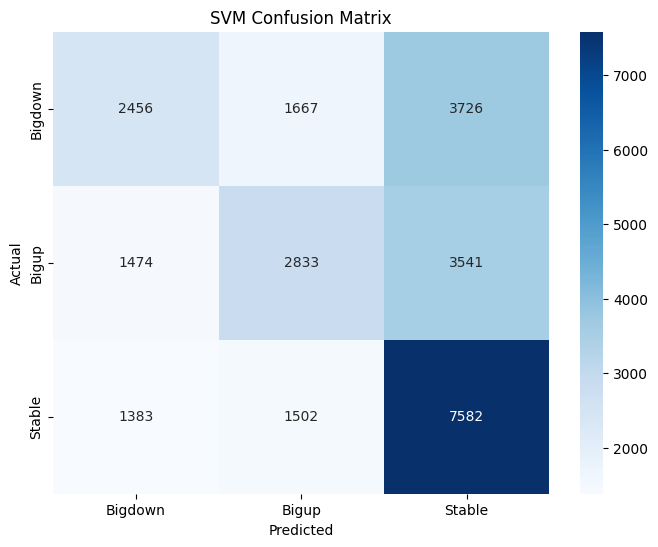


--- SVM Train Results ---
              precision    recall  f1-score   support

     Bigdown       0.52      0.42      0.46     15770
       Bigup       0.53      0.45      0.49     15771
      Stable       0.55      0.69      0.61     21039

    accuracy                           0.54     52580
   macro avg       0.53      0.52      0.52     52580
weighted avg       0.53      0.54      0.53     52580



In [ ]:
svm_test_predictions = clf.predict(X_test_scaled)
svm_train_predictions = clf.predict(X_train_scaled)

print(f"Accuracy: {accuracy_score(y_test, svm_test_predictions):.4f}")
print("\n--- SVM Test Results ---")
print(classification_report(y_test, svm_test_predictions, target_names=['Bigdown', 'Bigup', 'Stable']))

cm_svm = confusion_matrix(y_test, svm_test_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', xticklabels=['Bigdown', 'Bigup','Stable'], yticklabels=['Bigdown', 'Bigup','Stable'])
plt.title("SVM Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

print("\n--- SVM Train Results ---")
print(classification_report(y_train, svm_train_predictions, target_names=['Bigdown', 'Bigup', 'Stable']))

In [ ]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
import pandas as pd
import numpy as np

drop_cols = [
    'label', 'date', 'type',
    'down_days_7',
    'taker_buy_volume',
    'z_score',
    'taker_buy_ratio',
    'taker_sell_ratio',
    'negative_momentum',
]

X = df.drop(columns=drop_cols)
y = df['label']

groups = df['type']

logo = LeaveOneGroupOut()

results = []

for fold, (train_idx, test_idx) in enumerate(logo.split(X, y, groups), 1):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    test_coin = groups.iloc[test_idx].unique()[0]

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    clf = SVC(
    kernel='rbf',
    C=50,
    gamma='scale',
    class_weight='balanced',
    random_state=42
    )

    clf.fit(X_train_scaled, y_train)

    preds = clf.predict(X_test_scaled)

    acc = accuracy_score(y_test, preds)
    macro_f1 = f1_score(y_test, preds, average='macro')
    weighted_f1 = f1_score(y_test, preds, average='weighted')

    results.append({
        'test_coin': test_coin,
        'accuracy': acc,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1
    })

    print(f"\n===== Fold {fold} | Test coin: {test_coin} =====")
    print(classification_report(y_test, preds))

results_df = pd.DataFrame(results)

print("\nResults per coin:")
print(results_df)

print("\nAverage results:")
print(results_df[['accuracy', 'macro_f1', 'weighted_f1']].mean())


===== Fold 1 | Test coin: ADA =====
              precision    recall  f1-score   support

     Bigdown       0.45      0.42      0.43      3681
       Bigup       0.46      0.47      0.47      3682
      Stable       0.56      0.59      0.57      4924

    accuracy                           0.50     12287
   macro avg       0.49      0.49      0.49     12287
weighted avg       0.50      0.50      0.50     12287


===== Fold 2 | Test coin: AVAX =====
              precision    recall  f1-score   support

     Bigdown       0.45      0.42      0.43      3681
       Bigup       0.46      0.47      0.47      3682
      Stable       0.56      0.59      0.57      4924

    accuracy                           0.50     12287
   macro avg       0.49      0.49      0.49     12287
weighted avg       0.50      0.50      0.50     12287


===== Fold 3 | Test coin: BNB =====
              precision    recall  f1-score   support

     Bigdown       0.42      0.18      0.25      4164
       Bigup     

In [ ]:
results_df = pd.DataFrame(results)

print(results_df)

print("\nAverage Results:")
print(results_df[['accuracy', 'macro_f1', 'weighted_f1']].mean())

  test_coin  accuracy  macro_f1  weighted_f1
0       ADA  0.500366  0.490705     0.498984
1      AVAX  0.500366  0.490705     0.498984
2       BNB  0.457015  0.378874     0.401044
3      DOGE  0.452475  0.390034     0.410395
4       ETH  0.328313  0.299822     0.289950
5       SOL  0.404259  0.404170     0.407795

Average Results:
accuracy       0.440466
macro_f1       0.409052
weighted_f1    0.417859
dtype: float64


# logistic regression

In [ ]:
from sklearn.linear_model import LogisticRegression
drop_cols = [
    'label', 'date', 'type',
    'down_days_7',
    'taker_buy_volume',
    'z_score','taker_buy_ratio','taker_sell_ratio', 'negative_momentum',
]
X_train = train_df.drop(columns=drop_cols)
y_train = train_df['label']

X_test = test_df.drop(columns=drop_cols)
y_test = test_df['label']
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(
        multi_class='multinomial',
        solver='saga',
        class_weight='balanced',
        max_iter=5000,
        random_state=42,
        n_jobs=-1
    )
print(f"Training Logistic Regression... Train: {len(X_train_scaled)}")
log_reg.fit(X_train_scaled, y_train)

Training Logistic Regression... Train: 52580


C:\Users\ibrah\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'saga'
,max_iter,5000
,multi_class,'multinomial'



--- Logistic Regression Test Results ---
              precision    recall  f1-score   support

     Bigdown       0.37      0.26      0.31      7849
       Bigup       0.39      0.36      0.37      7848
      Stable       0.51      0.65      0.57     10467

    accuracy                           0.45     26164
   macro avg       0.42      0.42      0.42     26164
weighted avg       0.43      0.45      0.43     26164



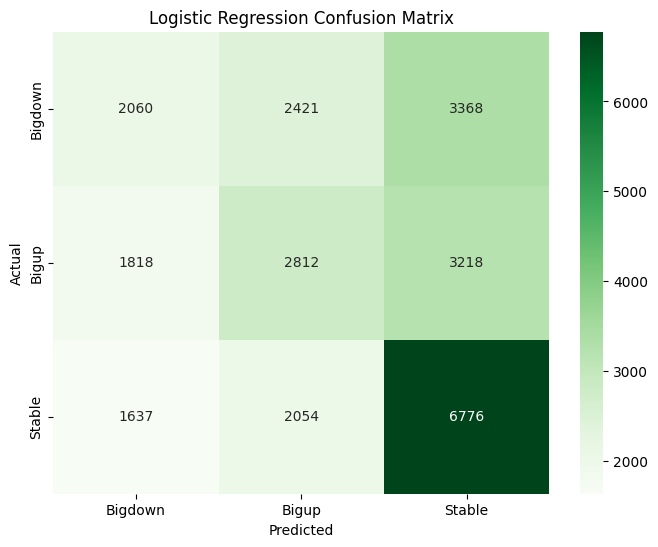

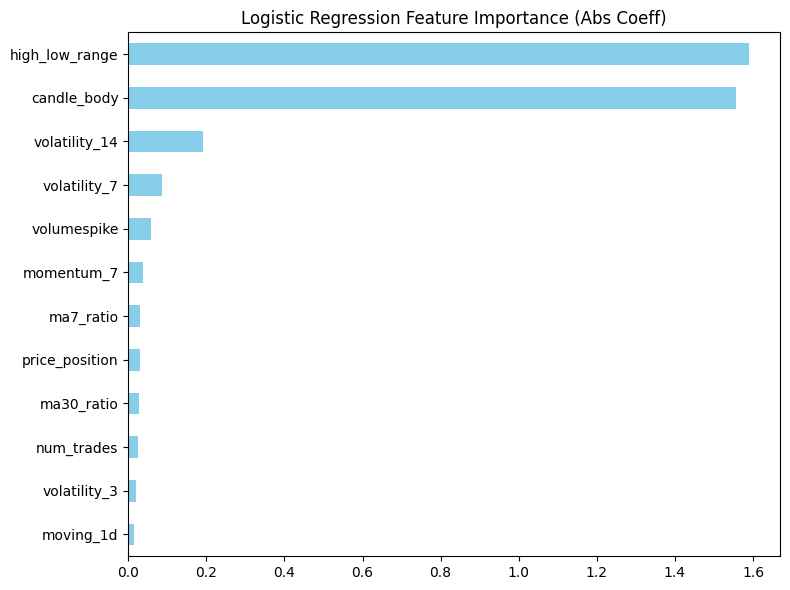

--- Logistic Regression Train Results ---
              precision    recall  f1-score   support

     Bigdown       0.37      0.27      0.31     15770
       Bigup       0.40      0.34      0.36     15771
      Stable       0.50      0.66      0.57     21039

    accuracy                           0.44     52580
   macro avg       0.42      0.42      0.41     52580
weighted avg       0.43      0.44      0.43     52580



In [ ]:
log_test_predictions = log_reg.predict(X_test_scaled)
log_train_predictions = log_reg.predict(X_train_scaled)

print("\n--- Logistic Regression Test Results ---")
print(classification_report(y_test, log_test_predictions, target_names=['Bigdown', 'Bigup', 'Stable']))

cm_log = confusion_matrix(y_test, log_test_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Greens', xticklabels=['Bigdown', 'Bigup','Stable'], yticklabels=['Bigdown', 'Bigup','Stable'])
plt.title("Logistic Regression Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

importance = np.mean(np.abs(log_reg.coef_), axis=0)
feat_imp_log = pd.Series(importance, index=X_train.columns)
feat_imp_log.sort_values().plot(kind='barh', figsize=(8, 6), color='skyblue')
plt.title("Logistic Regression Feature Importance (Abs Coeff)")
plt.tight_layout()
plt.show()

print("--- Logistic Regression Train Results ---")
print(classification_report(y_train, log_train_predictions, target_names=['Bigdown', 'Bigup', 'Stable']))

In [ ]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
import pandas as pd
import numpy as np

drop_cols = [
    'label', 'date', 'type',
    'down_days_7',
    'taker_buy_volume',
    'z_score',
    'taker_buy_ratio',
    'taker_sell_ratio',
    'negative_momentum',
]

X = df.drop(columns=drop_cols)
y = df['label']
groups = df['type']

logo = LeaveOneGroupOut()
results = []

for fold, (train_idx, test_idx) in enumerate(logo.split(X, y, groups), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    test_coin = groups.iloc[test_idx].unique()[0]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    log_reg = LogisticRegression(
        multi_class='multinomial',
        solver='saga',
        class_weight='balanced',
        max_iter=5000,
        random_state=42,
        n_jobs=-1
    )

    log_reg.fit(X_train_scaled, y_train)

    preds = log_reg.predict(X_test_scaled)

    acc = accuracy_score(y_test, preds)
    macro_f1 = f1_score(y_test, preds, average='macro')
    weighted_f1 = f1_score(y_test, preds, average='weighted')

    results.append({
        'test_coin': test_coin,
        'accuracy': acc,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1
    })

    print(f"\n===== Fold {fold} | Test coin: {test_coin} =====")
    print(classification_report(y_test, preds))

C:\Users\ibrah\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\ibrah\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



===== Fold 1 | Test coin: ADA =====
              precision    recall  f1-score   support

     Bigdown       0.36      0.30      0.33      3681
       Bigup       0.37      0.38      0.37      3682
      Stable       0.53      0.57      0.55      4924

    accuracy                           0.44     12287
   macro avg       0.42      0.42      0.42     12287
weighted avg       0.43      0.44      0.43     12287



C:\Users\ibrah\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\ibrah\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



===== Fold 2 | Test coin: AVAX =====
              precision    recall  f1-score   support

     Bigdown       0.36      0.30      0.33      3681
       Bigup       0.37      0.38      0.37      3682
      Stable       0.53      0.57      0.55      4924

    accuracy                           0.44     12287
   macro avg       0.42      0.42      0.42     12287
weighted avg       0.43      0.44      0.43     12287



C:\Users\ibrah\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\ibrah\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



===== Fold 3 | Test coin: BNB =====
              precision    recall  f1-score   support

     Bigdown       0.41      0.15      0.22      4164
       Bigup       0.45      0.19      0.27      4165
      Stable       0.46      0.87      0.60      5548

    accuracy                           0.45     13877
   macro avg       0.44      0.41      0.36     13877
weighted avg       0.44      0.45      0.39     13877



C:\Users\ibrah\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



===== Fold 4 | Test coin: DOGE =====
              precision    recall  f1-score   support

     Bigdown       0.39      0.23      0.29      4168
       Bigup       0.41      0.31      0.35      4166
      Stable       0.49      0.73      0.59      5543

    accuracy                           0.45     13877
   macro avg       0.43      0.42      0.41     13877
weighted avg       0.44      0.45      0.43     13877



C:\Users\ibrah\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\ibrah\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



===== Fold 5 | Test coin: ETH =====
              precision    recall  f1-score   support

     Bigdown       0.31      0.65      0.42      4166
       Bigup       0.41      0.28      0.33      4165
      Stable       0.53      0.20      0.30      5546

    accuracy                           0.36     13877
   macro avg       0.42      0.38      0.35     13877
weighted avg       0.43      0.36      0.34     13877



C:\Users\ibrah\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\ibrah\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



===== Fold 6 | Test coin: SOL =====
              precision    recall  f1-score   support

     Bigdown       0.37      0.33      0.35      3759
       Bigup       0.37      0.44      0.40      3759
      Stable       0.54      0.50      0.52      5021

    accuracy                           0.43     12539
   macro avg       0.43      0.43      0.42     12539
weighted avg       0.44      0.43      0.43     12539



In [ ]:
results_df = pd.DataFrame(results)

print(results_df)

print("\nAverage Results:")
print(results_df[['accuracy', 'macro_f1', 'weighted_f1']].mean())

  test_coin  accuracy  macro_f1  weighted_f1
0       ADA  0.435338  0.417772     0.431150
1      AVAX  0.435338  0.417772     0.431150
2       BNB  0.451683  0.363343     0.386955
3      DOGE  0.453412  0.408696     0.426294
4       ETH  0.363695  0.350033     0.344588
5       SOL  0.433767  0.424827     0.434346

Average Results:
accuracy       0.428872
macro_f1       0.397074
weighted_f1    0.409081
dtype: float64


KNN

In [16]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.inspection import permutation_importance
from sklearn.model_selection import LeaveOneGroupOut
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [17]:
drop_cols = ['label', 'date', 'type', 'down_days_7', 'taker_buy_volume',
             'z_score', 'taker_buy_ratio', 'taker_sell_ratio', 'negative_momentum']

X_train = train_df.drop(columns=drop_cols)
X_test  = test_df.drop(columns=drop_cols)

y_train = train_df['label']
y_test  = test_df['label']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

 KNN Test Results 
              precision    recall  f1-score   support

     Bigdown       0.71      0.61      0.65      7849
       Bigup       0.70      0.63      0.66      7848
      Stable       0.68      0.81      0.74     10467

    accuracy                           0.69     26164
   macro avg       0.69      0.68      0.68     26164
weighted avg       0.69      0.69      0.69     26164



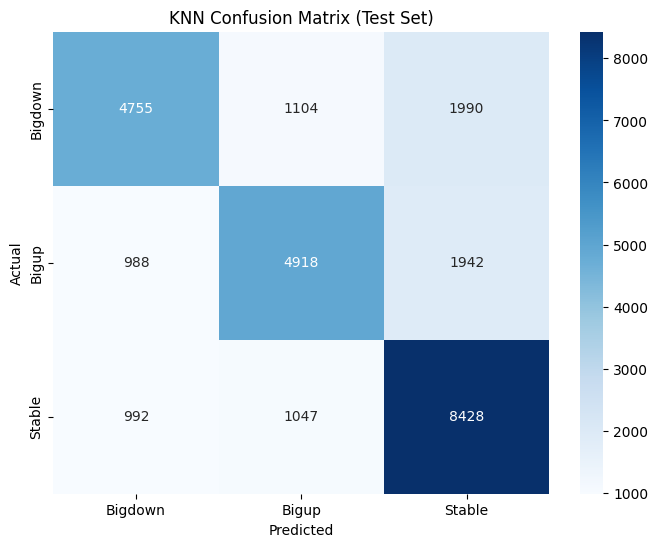

In [20]:
knn = KNeighborsClassifier(
    n_neighbors=7,
    weights='distance',
    metric='euclidean',
    n_jobs=-1
)

knn.fit(X_train_scaled, y_train)

print(" KNN Test Results ")
print(classification_report(y_test, knn.predict(X_test_scaled),
                            target_names=['Bigdown', 'Bigup', 'Stable']))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, knn.predict(X_test_scaled)),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bigdown', 'Bigup', 'Stable'],
            yticklabels=['Bigdown', 'Bigup', 'Stable'])
plt.title('KNN Confusion Matrix (Test Set)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [22]:

logo = LeaveOneGroupOut()
knn_cv_results = []

for fold, (train_idx, test_idx) in enumerate(logo.split(X, y, groups), 1):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
    coin = groups.iloc[test_idx].unique()[0]

    scaler_cv = StandardScaler()
    X_tr_scaled = scaler_cv.fit_transform(X_tr)
    X_te_scaled = scaler_cv.transform(X_te)

    model = KNeighborsClassifier(n_neighbors=7, weights='distance', n_jobs=-1)
    model.fit(X_tr_scaled, y_tr)
    pred = model.predict(X_te_scaled)

    knn_cv_results.append({
        'test_coin': coin,
        'accuracy': accuracy_score(y_te, pred),
        'macro_f1': f1_score(y_te, pred, average='macro'),
        'weighted_f1': f1_score(y_te, pred, average='weighted')
    })

    print(f"\nFold {fold} | Test Coin: {coin} ")
    print(classification_report(y_te, pred, target_names=['Bigdown', 'Bigup', 'Stable']))


cv_df = pd.DataFrame(knn_cv_results)
print("\n" + "="*60)
print(cv_df.round(4))
print("\nKNN Average Performance:")
print(cv_df.mean(numeric_only=True).round(4))


Fold 1 | Test Coin: ADA 
              precision    recall  f1-score   support

     Bigdown       1.00      1.00      1.00      3681
       Bigup       1.00      1.00      1.00      3682
      Stable       1.00      1.00      1.00      4924

    accuracy                           1.00     12287
   macro avg       1.00      1.00      1.00     12287
weighted avg       1.00      1.00      1.00     12287


Fold 2 | Test Coin: AVAX 
              precision    recall  f1-score   support

     Bigdown       1.00      1.00      1.00      3681
       Bigup       1.00      1.00      1.00      3682
      Stable       1.00      1.00      1.00      4924

    accuracy                           1.00     12287
   macro avg       1.00      1.00      1.00     12287
weighted avg       1.00      1.00      1.00     12287


Fold 3 | Test Coin: BNB 
              precision    recall  f1-score   support

     Bigdown       0.34      0.28      0.31      4164
       Bigup       0.34      0.27      0.30      4